In [16]:
import seaborn as sns
import pandas as pd 

df = pd.read_csv('data_cleaned_2021.csv')

df.head()

# job description parsing (python, etc)


,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


In [30]:
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
# salary parsing

df = df[df['Salary Estimate'] != '-1']

salary = df['Salary Estimate'].apply(lambda x: x.split('(')[0])
minus_KD = salary.apply(lambda x: x.replace('K','').replace('$',''))

df['hourly'] = df['Salary Estimate'].apply(lambda x: 1 if 'per hour' in x.lower() else 0)

df['employer_provided'] = df['Salary Estimate'].apply(lambda x: 1 if 'employer provided salary:' in x.lower() else 0)

min_hrs = minus_KD.apply(lambda x: x.lower().replace('per hour','').replace('employer provided salary:',''))

df['min_salary'] = min_hrs.apply(lambda x: int(x.split('-')[0]))
df['max_salary'] = min_hrs.apply(lambda x: int(x.split('-')[1]))
df['avg_salary'] = (df.min_salary + df.max_salary)/2


df[['Salary Estimate', 'min_salary', 'max_salary', 'avg_salary', 'hourly', 'employer_provided']].head()


,Salary Estimate,min_salary,max_salary,avg_salary,hourly,employer_provided
0,$53K-$91K (Glassdoor est.),53,91,72.0,0,0
1,$63K-$112K (Glassdoor est.),63,112,87.5,0,0
2,$80K-$90K (Glassdoor est.),80,90,85.0,0,0
3,$56K-$97K (Glassdoor est.),56,97,76.5,0,0
4,$86K-$143K (Glassdoor est.),86,143,114.5,0,0


In [18]:
# company name text only
df['company_txt'] = df.apply(lambda x: x['Company Name'] if x['Rating'] < 0 else x['Company Name'][:-3], axis=1)

In [19]:
# state field 
df['state'] = df['Location'].apply(lambda x: x.split(',')[1])

df.head()

,index,Job Title,Salary Estimate,Job Description,Rating,Company Name,Location,Headquarters,Size,Founded,...,google_an,job_title_sim,seniority_by_title,Degree,hourly,employer_provided,min_salary,max_salary,avg_salary,state
0,0,Data Scientist,$53K-$91K (Glassdoor est.),"Data Scientist\nLocation: Albuquerque, NM\nEdu...",3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,data scientist,na,M,0,0,53,91,72.0,NM
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),What You Will Do:\n\nI. General Summary\n\nThe...,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,data scientist,na,M,0,0,63,112,87.5,MD
2,2,Data Scientist,$80K-$90K (Glassdoor est.),"KnowBe4, Inc. is a high growth information sec...",4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,data scientist,na,M,0,0,80,90,85.0,FL
3,3,Data Scientist,$56K-$97K (Glassdoor est.),*Organization and Job ID**\nJob ID: 310709\n\n...,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,data scientist,na,na,0,0,56,97,76.5,WA
4,4,Data Scientist,$86K-$143K (Glassdoor est.),Data Scientist\nAffinity Solutions / Marketing...,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,data scientist,na,na,0,0,86,143,114.5,NY


In [20]:
df['some_state'] = df.apply(lambda x: 1 if x.Location == x.Headquarters else 0, axis = 1)

# age of company
df['age'] = df['Founded'].apply(lambda x: x if x < 1 else 2026 - x)

# parsing of job description (python, etc)
df['python_yn'] = df['Job Description'].apply(lambda x: 1 if 'python' in x.lower() else 0)

# R studio
df['R_yn'] = df['Job Description'].apply(lambda x: 1 if 'r studio' in x.lower() or 'r-studio' in x.lower() else 0)

# spark
df['spark_yn'] = df['Job Description'].apply(lambda x: 1 if 'spark' in x.lower() else 0)

# aws
df['aws_yn'] = df['Job Description'].apply(lambda x: 1 if 'aws' in x.lower() else 0)

# excel
df['excel_yn'] = df['Job Description'].apply(lambda x: 1 if 'excel' in x.lower() else 0)

df.columns



Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Hourly', 'Employer provided', 'Lower Salary', 'Upper Salary',
       'Avg Salary(K)', 'company_txt', 'Job Location', 'Age', 'Python',
       'spark', 'aws', 'excel', 'sql', 'sas', 'keras', 'pytorch', 'scikit',
       'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an',
       'job_title_sim', 'seniority_by_title', 'Degree', 'hourly',
       'employer_provided', 'min_salary', 'max_salary', 'avg_salary', 'state',
       'some_state', 'age', 'python_yn', 'R_yn', 'spark_yn', 'aws_yn',
       'excel_yn'],
      dtype='object')

In [21]:
df.to_csv('data_cleaned_2021_final.csv', index=False)

In [22]:
def title_simplifier(title):
    if 'data scientist' in title.lower():
        return 'data scientist'
    elif 'data engineer' in title.lower():
        return 'data engineer'
    elif 'analyst' in title.lower():
        return 'analyst'
    elif 'machine learning' in title.lower():
        return 'machine learning engineer'
    elif 'manager' in title.lower():
        return 'manager'
    elif 'director' in title.lower():
        return 'director'
    else:
        return 'na'
    
def seniority_simplifier(title):
    if 'sr' in title.lower() or 'senior' in title.lower() or 'lead' in title.lower() or 'principal' in title.lower():
        return 'senior'
    elif 'jr' in title.lower() or 'junior' in title.lower() or 'intern' in title.lower():
        return 'junior'
    else:
        return 'na'



In [23]:
df['job_simp'] = df['Job Title'].apply(title_simplifier)
df['seniority'] = df['Job Title'].apply(seniority_simplifier)
# df['job_state'] = df[job_state].apply(lambda x: x.strip() if x.strip().lower() != 'los angeles' else 'CA')

df.columns


Index(['index', 'Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Hourly', 'Employer provided', 'Lower Salary', 'Upper Salary',
       'Avg Salary(K)', 'company_txt', 'Job Location', 'Age', 'Python',
       'spark', 'aws', 'excel', 'sql', 'sas', 'keras', 'pytorch', 'scikit',
       'tensor', 'hadoop', 'tableau', 'bi', 'flink', 'mongo', 'google_an',
       'job_title_sim', 'seniority_by_title', 'Degree', 'hourly',
       'employer_provided', 'min_salary', 'max_salary', 'avg_salary', 'state',
       'some_state', 'age', 'python_yn', 'R_yn', 'spark_yn', 'aws_yn',
       'excel_yn', 'job_simp', 'seniority'],
      dtype='object')

In [24]:
#define job description length 
df['desc_len'] = df['Job Description'].apply(lambda x: len(x))

In [25]:
#competitor count 
df['num_comp'] = df['Competitors'].apply(lambda x: len(x.split(',')) if x != '-1' else 0)
df['Competitors']

0                                                     -1
1                                                     -1
2                                                     -1
3      Oak Ridge National Laboratory, National Renewa...
4                   Commerce Signals, Cardlytics, Yodlee
                             ...                        
737                           Pfizer, AstraZeneca, Merck
738                      See Tickets, TicketWeb, Vendini
739                                                   -1
740                                                   -1
741                                                   -1
Name: Competitors, Length: 742, dtype: object

In [26]:
#hourly wage to annual salary
df['min_salary'] = df.apply(lambda x: x['min_salary']*2 if x['hourly'] ==1 else x['min_salary'], axis=1)
df['max_salary'] = df.apply(lambda x: x['max_salary']*2 if x['hourly'] ==1 else x['max_salary'], axis=1)
df['avg_salary'] = (df.min_salary + df.max_salary)/2

In [27]:
#remove \n from company text
df['company_txt'] = df.company_txt.apply(lambda x: x.replace('\n','').strip())

In [28]:
df.describe()

,index,Rating,Founded,Hourly,Employer provided,Lower Salary,Upper Salary,Avg Salary(K),Age,Python,...,avg_salary,some_state,age,python_yn,R_yn,spark_yn,aws_yn,excel_yn,desc_len,num_comp
count,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,...,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000,742.000000
mean,469.129380,3.618868,1837.154987,0.032345,0.022911,74.754717,128.214286,101.484501,47.524259,0.528302,...,101.434636,0.557951,52.187332,0.528302,0.002695,0.225067,0.237197,0.522911,3869.545822,1.053908
std,279.793117,0.801210,497.183763,0.177034,0.149721,30.945892,45.128650,37.482449,53.839080,0.499535,...,37.546122,0.496965,54.156829,0.499535,0.051882,0.417908,0.425651,0.499812,1521.495868,1.384239
min,0.000000,-1.000000,-1.000000,0.000000,0.000000,15.000000,16.000000,15.500000,-1.000000,0.000000,...,15.500000,0.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,407.000000,0.000000
25%,221.500000,3.300000,1939.000000,0.000000,0.000000,52.000000,96.000000,73.500000,12.000000,0.000000,...,73.500000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2801.000000,0.000000
50%,472.500000,3.700000,1988.000000,0.000000,0.000000,69.500000,124.000000,97.500000,25.000000,1.000000,...,97.500000,1.000000,30.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3731.000000,0.000000
75%,707.750000,4.000000,2007.000000,0.000000,0.000000,91.000000,155.000000,122.500000,60.000000,1.000000,...,122.500000,1.000000,65.000000,1.000000,0.000000,0.000000,0.000000,1.000000,4740.000000,3.000000
max,955.000000,5.000000,2019.000000,1.000000,1.000000,202.000000,306.000000,254.000000,277.000000,1.000000,...,254.000000,1.000000,282.000000,1.000000,1.000000,1.000000,1.000000,1.000000,10051.000000,4.000000


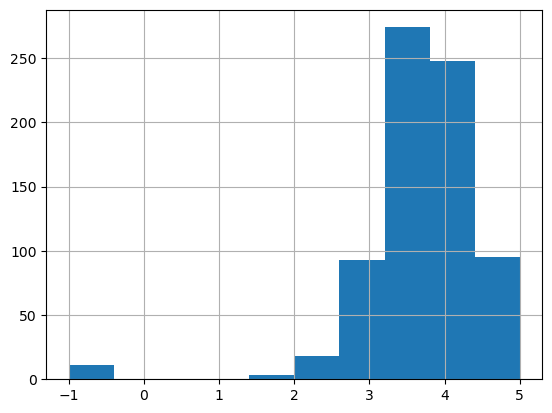

Column: Location
Location
New York, NY                         55
San Francisco, CA                    49
Cambridge, MA                        47
Chicago, IL                          32
Boston, MA                           23
                                     ..
Santa Fe Springs, Los Angeles, CA     1
Kansas City, MO                       1
Columbia, SC                          1
Red Bank, NJ                          1
Olympia, WA                           1
Name: count, Length: 200, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


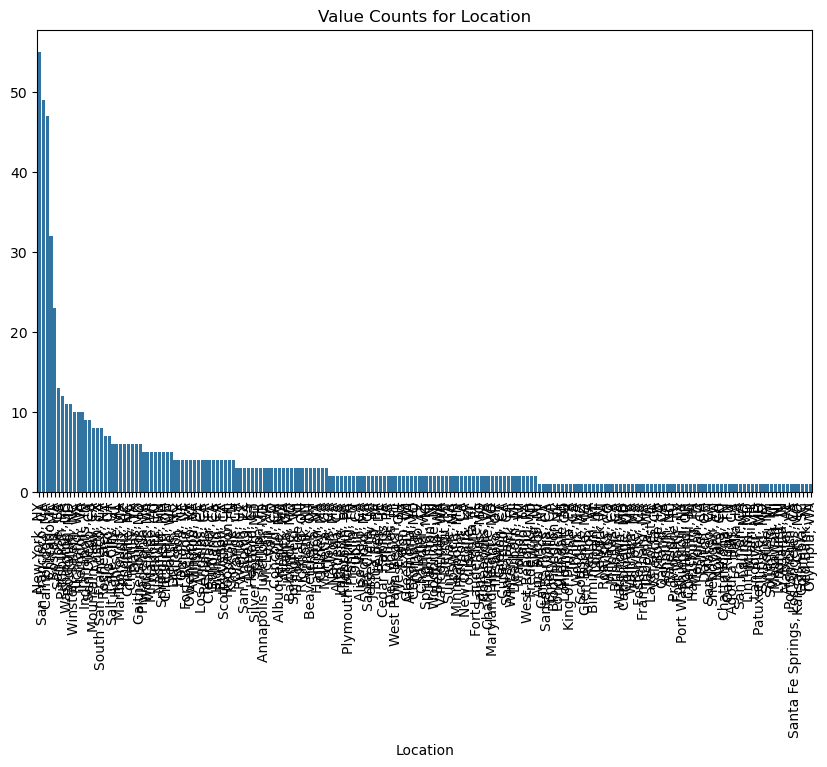

Column: Headquarters
Headquarters
New York, NY            52
San Francisco, CA       42
Chicago, IL             30
Cambridge, MA           20
Springfield, MA         14
                        ..
West Hills, CA           1
Fort Worth, TX           1
Kansas City, MO          1
Santa Fe Springs, CA     1
Centennial, CO           1
Name: count, Length: 198, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


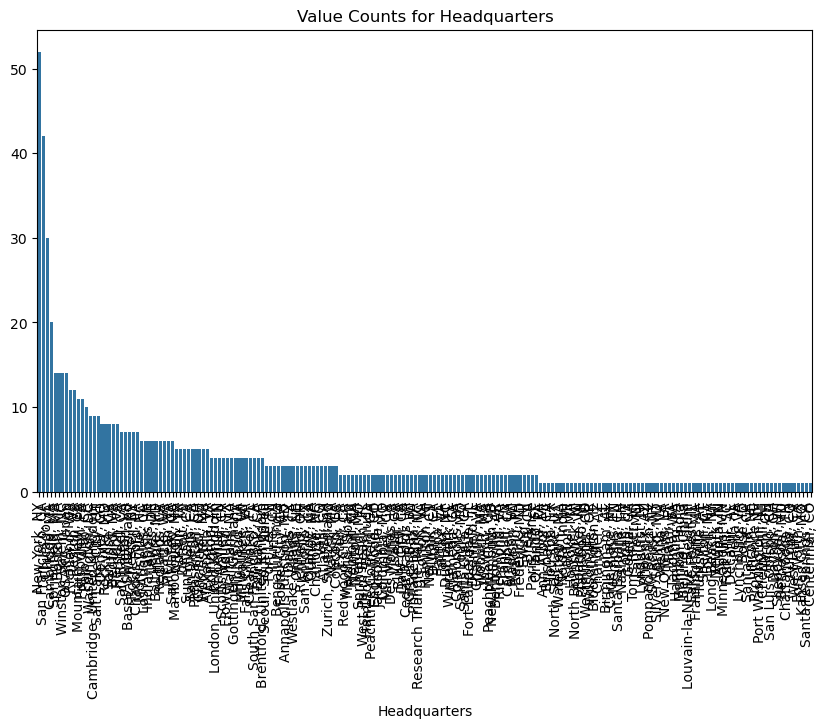

Column: Size
Size
1001 - 5000      150
501 - 1000       134
10000+           130
201 - 500        117
51 - 200          94
5001 - 10000      76
1 - 50            31
unknown           10
Name: count, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


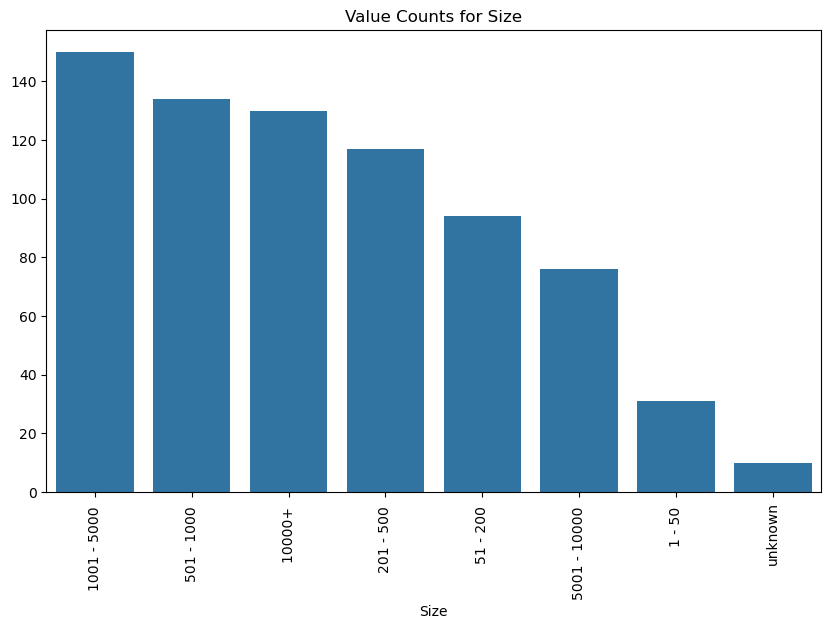

Column: Type of ownership
Type of ownership
Company - Private                 410
Company - Public                  193
Nonprofit Organization             55
Subsidiary or Business Segment     34
Government                         15
Hospital                           15
College / University               13
Other Organization                  5
School / School District            2
Name: count, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


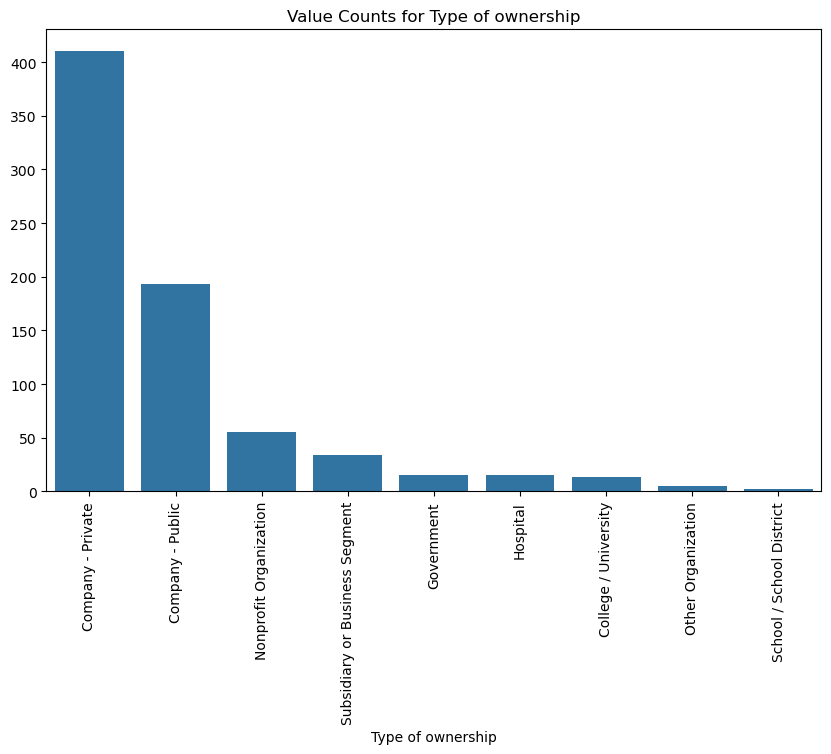

Column: Industry
Industry
Biotech & Pharmaceuticals                   112
Insurance Carriers                           63
Computer Hardware & Software                 59
IT Services                                  50
Health Care Services & Hospitals             49
Enterprise Software & Network Solutions      42
Internet                                     29
Consulting                                   29
Aerospace & Defense                          25
Advertising & Marketing                      25
Consumer Products Manufacturing              20
Research & Development                       19
Colleges & Universities                      16
Energy                                       14
Banks & Credit Unions                        12
Federal Agencies                             11
-1                                           10
Staffing & Outsourcing                       10
Travel Agencies                               8
Lending                                       8
Food & Beverag

C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


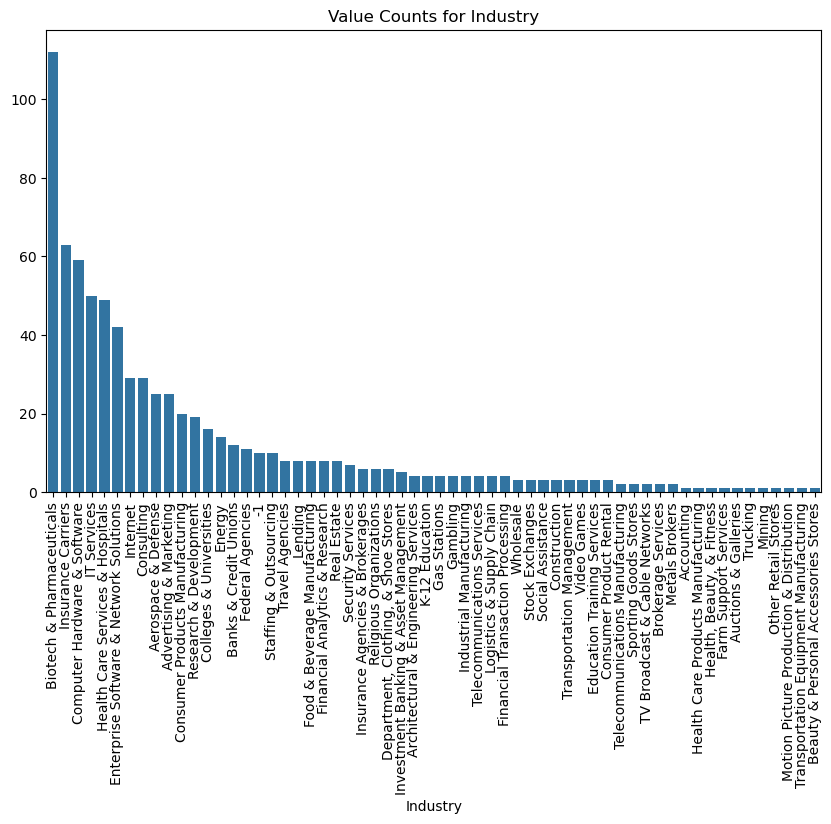

Column: Sector
Sector
Information Technology                180
Biotech & Pharmaceuticals             112
Business Services                      97
Insurance                              69
Health Care                            49
Finance                                42
Manufacturing                          34
Aerospace & Defense                    25
Education                              23
Retail                                 15
Oil, Gas, Energy & Utilities           14
Government                             11
-1                                     10
Non-Profit                              9
Transportation & Logistics              8
Real Estate                             8
Travel & Tourism                        8
Telecommunications                      6
Media                                   6
Arts, Entertainment & Recreation        4
Consumer Services                       4
Mining & Metals                         3
Construction, Repair & Maintenance      3
Agriculture 

C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


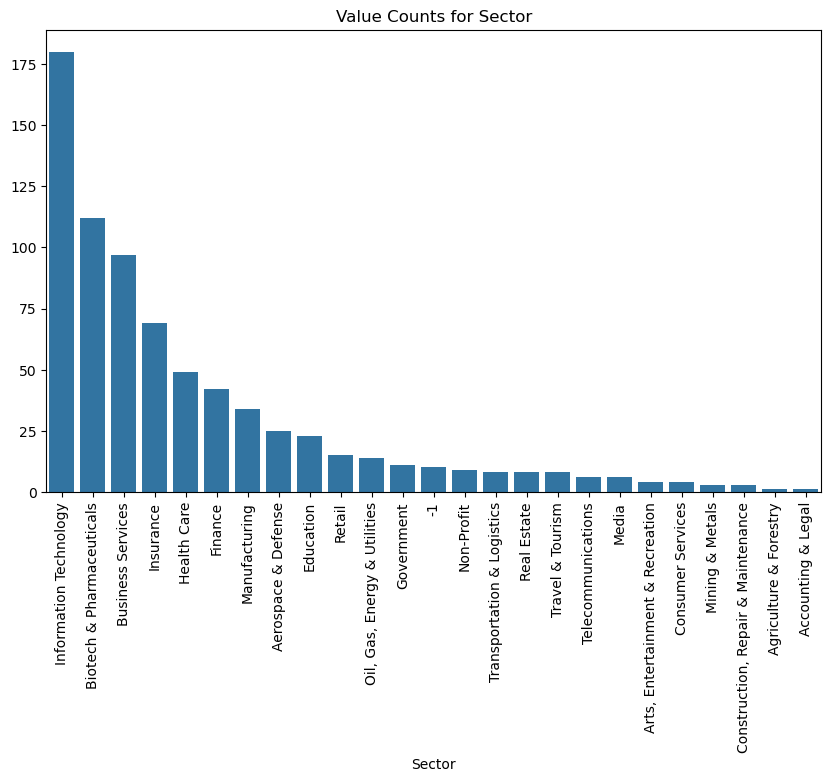

Column: Revenue
Revenue
Unknown / Non-Applicable            204
$10+ billion (USD)                  124
$100 to $500 million (USD)           91
$1 to $2 billion (USD)               60
$500 million to $1 billion (USD)     57
$50 to $100 million (USD)            46
$25 to $50 million (USD)             40
$2 to $5 billion (USD)               39
$10 to $25 million (USD)             32
$5 to $10 billion (USD)              19
$5 to $10 million (USD)              18
$1 to $5 million (USD)                8
Less than $1 million (USD)            4
Name: count, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


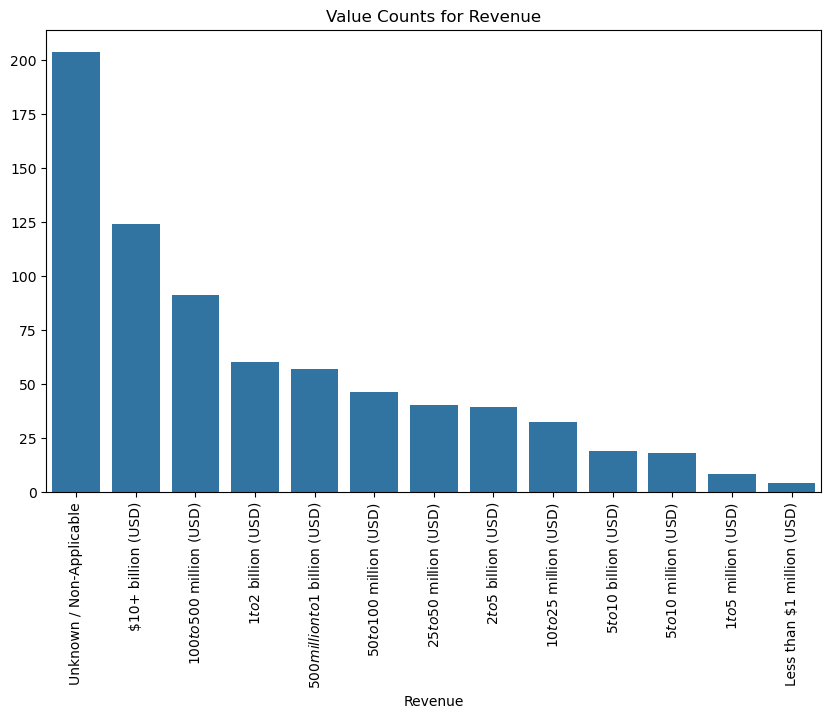

Column: Job Title
Job Title
Data Scientist                     131
Data Engineer                       53
Senior Data Scientist               34
Data Analyst                        15
Senior Data Engineer                14
                                  ... 
Data Scientist/ML Engineer           1
Sr. Data Scientist                   1
Data Engineer 4 - Contract           1
Data Analyst - Asset Management      1
Machine Learning Engineer (NLP)      1
Name: count, Length: 264, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


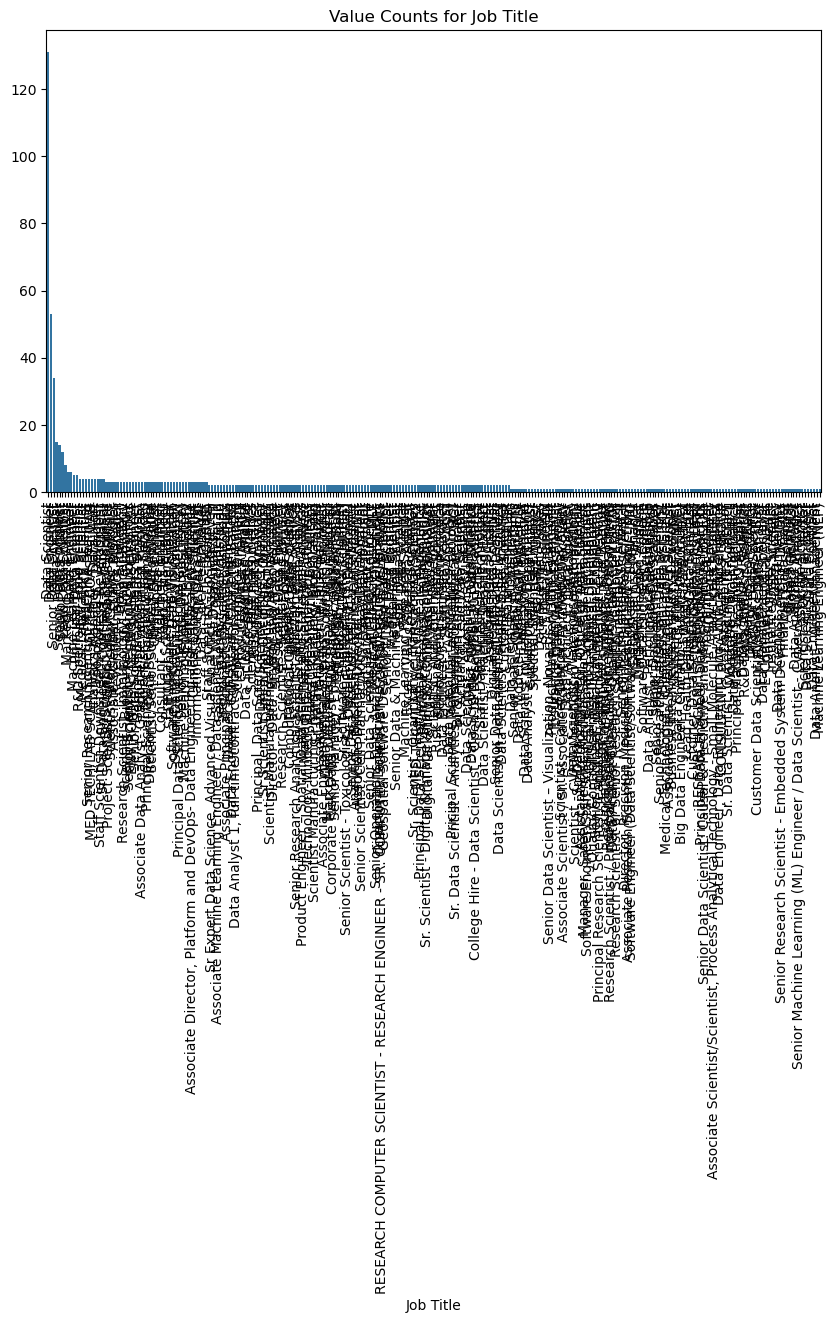

Column: python_yn
python_yn
1    392
0    350
Name: count, dtype: int64




C:\Users\2504\AppData\Local\Temp\ipykernel_13352\1301134020.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  chart.set_xticklabels(chart.get_xticklabels(), rotation=90)


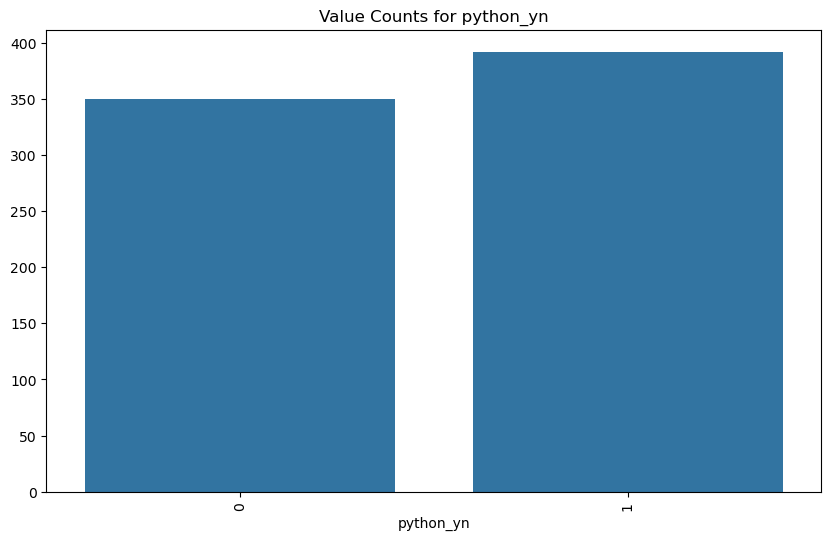

In [31]:
df.Rating.hist()
plt.show()

df_cat = df[["Location", "Headquarters", "Size", "Type of ownership", "Industry", "Sector", "Revenue", "Job Title", "python_yn"]]

for col in df_cat.columns:
    cat_num = df_cat[col].value_counts()
    print(f"Column: {col}")
    print(cat_num)
    print("\n")
    plt.figure(figsize=(10, 6))
    chart = sns.barplot(x=cat_num.index, y=cat_num.values)
    chart.set_xticklabels(chart.get_xticklabels(), rotation=90)
    plt.title(f'Value Counts for {col}')
    plt.show()